# 08 Subgroup Error Analysis

This notebook evaluates subgroup-level error patterns for the selected XGBoost model on the fixed temporal holdout test set.

The holdout predictions are divided into U.S.-based and non-U.S.-based startups using the `is_usa` indicator. The notebook reports subgroup-specific confusion-matrix counts, false-positive rates, and false-negative rates, and saves the table and confusion-matrix figure used in the thesis.

## 1. Imports and paths

This section loads the required libraries and defines the input and output locations.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.metrics import confusion_matrix


In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"

MODEL_COMPARISON_TABLES_DIR = TABLES_DIR / "model_comparison"
SUBGROUP_TABLES_DIR = TABLES_DIR / "subgroup_error_analysis"
SUBGROUP_FIGURES_DIR = FIGURES_DIR / "subgroup_error_analysis"

X_TEST_PATH = INTERIM_DIR / "X_test_temporal.csv"
Y_TEST_PATH = INTERIM_DIR / "y_test_temporal.csv"
MODEL_COMPARISON_PREDICTIONS_PATH = (
    MODEL_COMPARISON_TABLES_DIR / "model_comparison_holdout_predictions.csv"
)

TARGET_COL = "target"
SUBGROUP_COL = "is_usa"
MODEL_NAME = "XGBoost"

SUBGROUP_TABLES_DIR.mkdir(parents=True, exist_ok=True)
SUBGROUP_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATHS = {
    "subgroup_predictions": SUBGROUP_TABLES_DIR / "xgboost_holdout_predictions_with_subgroups.csv",
    "subgroup_error_table": SUBGROUP_TABLES_DIR / "subgroup_error_table.csv",
    "subgroup_rate_differences": SUBGROUP_TABLES_DIR / "subgroup_rate_differences.csv",
    "confusion_matrix_us_based": SUBGROUP_FIGURES_DIR / "confusion_matrix_us_based.png",
    "confusion_matrix_non_us_based": SUBGROUP_FIGURES_DIR / "confusion_matrix_non_us_based.png",
}


## 2. Helper functions

This section defines functions for checking inputs, loading the target variable, computing subgroup error rates, and drawing the confusion-matrix figure.

In [ ]:
def check_required_files(paths: list[Path]) -> None:
    missing = [str(path) for path in paths if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "The following required input files are missing:\n"
            + "\n".join(missing)
            + "\n\nRun the temporal split and model comparison notebooks first."
        )


def read_target(path: Path, target_col: str = TARGET_COL) -> pd.Series:
    target_df = pd.read_csv(path)
    if target_col not in target_df.columns:
        raise ValueError(
            f"Target column '{target_col}' was not found in {path}. "
            f"Available columns: {list(target_df.columns)}"
        )
    return target_df[target_col].astype(int)


def subgroup_label(value: int) -> str:
    return "U.S.-based" if int(value) == 1 else "Non-U.S.-based"


def compute_subgroup_error_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    subgroup_order = ["U.S.-based", "Non-U.S.-based"]

    for subgroup in subgroup_order:
        group_df = df.loc[df["subgroup"] == subgroup].copy()

        y_true = group_df["y_true"].astype(int)
        y_pred = group_df["y_pred"].astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        fpr_denominator = fp + tn
        fnr_denominator = fn + tp

        rows.append({
            "subgroup": subgroup,
            "true_negative": int(tn),
            "false_positive": int(fp),
            "false_negative": int(fn),
            "true_positive": int(tp),
            "false_positive_rate": fp / fpr_denominator if fpr_denominator > 0 else np.nan,
            "false_negative_rate": fn / fnr_denominator if fnr_denominator > 0 else np.nan,
        })

    return pd.DataFrame(rows)


def plot_subgroup_confusion_matrices(
    subgroup_error_table: pd.DataFrame,
) -> dict[str, plt.Figure]:
    subgroup_order = ["U.S.-based", "Non-U.S.-based"]
    confusion_matrix_figures = {}

    for subgroup in subgroup_order:
        row = subgroup_error_table.loc[
            subgroup_error_table["subgroup"] == subgroup
        ].iloc[0]

        matrix = np.array([
            [row["true_negative"], row["false_positive"]],
            [row["false_negative"], row["true_positive"]],
        ]).astype(int)

        fig, ax = plt.subplots(figsize=(5, 4))

        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=True,
            square=True,
            linewidths=1.5,
            linecolor="white",
            xticklabels=["Predicted\nclosed", "Predicted\nacquired"],
            yticklabels=["Actual\nclosed", "Actual\nacquired"],
            ax=ax,
        )

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelrotation=0)
        ax.tick_params(axis="y", labelrotation=0)

        plt.tight_layout()

        confusion_matrix_figures[subgroup] = fig
        plt.show()

    return confusion_matrix_figures


## 3. Load holdout predictions and subgroup information

This section loads the fixed holdout test set and the XGBoost predictions from the model comparison notebook.

In [9]:
required_paths = [
    X_TEST_PATH,
    Y_TEST_PATH,
    MODEL_COMPARISON_PREDICTIONS_PATH,
]

check_required_files(required_paths)

X_test = pd.read_csv(X_TEST_PATH)
y_test = read_target(Y_TEST_PATH)
holdout_predictions = pd.read_csv(MODEL_COMPARISON_PREDICTIONS_PATH)

if SUBGROUP_COL not in X_test.columns:
    raise ValueError(f"Column '{SUBGROUP_COL}' was not found in the holdout feature file.")

if "model" not in holdout_predictions.columns:
    raise ValueError("The holdout prediction file must contain a 'model' column.")

model_mask = (
    holdout_predictions["model"].astype(str).str.strip().str.lower()
    == MODEL_NAME.strip().lower()
)

xgb_predictions = (
    holdout_predictions
    .loc[model_mask]
    .reset_index(drop=True)
)

if xgb_predictions.empty:
    available_models = sorted(holdout_predictions["model"].dropna().astype(str).unique())
    raise ValueError(
        f"No holdout predictions were found for model '{MODEL_NAME}'. "
        f"Available models: {available_models}"
    )

if len(xgb_predictions) != len(X_test):
    raise ValueError(
        f"The number of XGBoost predictions ({len(xgb_predictions)}) does not match "
        f"the number of holdout rows ({len(X_test)})."
    )

if not np.array_equal(xgb_predictions["y_true"].astype(int).to_numpy(), y_test.to_numpy()):
    raise ValueError("The prediction file does not match the loaded holdout target values.")

subgroup_predictions = xgb_predictions.copy()
subgroup_predictions[SUBGROUP_COL] = X_test[SUBGROUP_COL].astype(int).to_numpy()
subgroup_predictions["subgroup"] = subgroup_predictions[SUBGROUP_COL].map(subgroup_label)

display(subgroup_predictions.head().round(2))


,y_true,y_pred,y_prob,model,is_usa,subgroup
0,0,0,0.47,XGBoost,0,Non-U.S.-based
1,1,1,0.54,XGBoost,0,Non-U.S.-based
2,0,0,0.45,XGBoost,1,U.S.-based
3,1,0,0.44,XGBoost,1,U.S.-based
4,1,1,0.77,XGBoost,1,U.S.-based


## 4. Subgroup error table

This section computes the confusion-matrix counts, false-positive rates, and false-negative rates for U.S.-based and non-U.S.-based startups.

In [10]:
subgroup_error_table = compute_subgroup_error_table(subgroup_predictions)

display(
    subgroup_error_table.assign(
        false_positive_rate=lambda df: df["false_positive_rate"].round(2),
        false_negative_rate=lambda df: df["false_negative_rate"].round(2),
    )
)


,subgroup,true_negative,false_positive,false_negative,true_positive,false_positive_rate,false_negative_rate
0,U.S.-based,98,137,69,553,0.58,0.11
1,Non-U.S.-based,95,30,70,89,0.24,0.44


## 5. Error-rate differences

This section computes the false-positive-rate and false-negative-rate differences reported in the results section.

In [11]:
us_row = subgroup_error_table.loc[subgroup_error_table["subgroup"] == "U.S.-based"].iloc[0]
non_us_row = subgroup_error_table.loc[subgroup_error_table["subgroup"] == "Non-U.S.-based"].iloc[0]

subgroup_rate_differences = pd.DataFrame([
    {
        "metric": "false_positive_rate",
        "us_based": us_row["false_positive_rate"],
        "non_us_based": non_us_row["false_positive_rate"],
        "absolute_difference": abs(us_row["false_positive_rate"] - non_us_row["false_positive_rate"]),
        "higher_subgroup": "U.S.-based"
        if us_row["false_positive_rate"] > non_us_row["false_positive_rate"]
        else "Non-U.S.-based",
    },
    {
        "metric": "false_negative_rate",
        "us_based": us_row["false_negative_rate"],
        "non_us_based": non_us_row["false_negative_rate"],
        "absolute_difference": abs(us_row["false_negative_rate"] - non_us_row["false_negative_rate"]),
        "higher_subgroup": "U.S.-based"
        if us_row["false_negative_rate"] > non_us_row["false_negative_rate"]
        else "Non-U.S.-based",
    },
])

display(
    subgroup_rate_differences.assign(
        us_based=lambda df: df["us_based"].round(2),
        non_us_based=lambda df: df["non_us_based"].round(2),
        absolute_difference=lambda df: df["absolute_difference"].round(2),
    )
)


,metric,us_based,non_us_based,absolute_difference,higher_subgroup
0,false_positive_rate,0.58,0.24,0.34,U.S.-based
1,false_negative_rate,0.11,0.44,0.33,Non-U.S.-based


## 6. Subgroup confusion matrices

This section creates the subgroup-specific confusion-matrix figure used in the thesis.

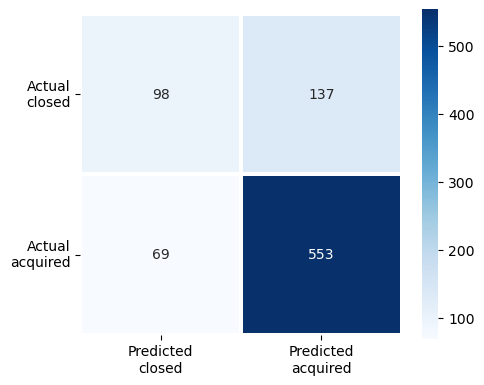

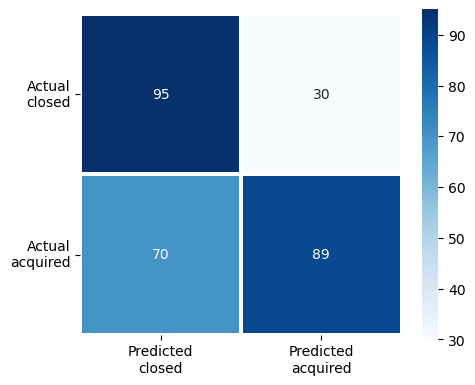

In [12]:
confusion_matrix_figures = plot_subgroup_confusion_matrices(
    subgroup_error_table=subgroup_error_table,
)


## 7. Save outputs

This section saves the subgroup prediction file, subgroup error table, error-rate differences, and confusion-matrix figures.


In [13]:
SUBGROUP_TABLES_DIR.mkdir(parents=True, exist_ok=True)
SUBGROUP_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

subgroup_predictions.to_csv(OUTPUT_PATHS["subgroup_predictions"], index=False)
subgroup_error_table.to_csv(OUTPUT_PATHS["subgroup_error_table"], index=False)
subgroup_rate_differences.to_csv(OUTPUT_PATHS["subgroup_rate_differences"], index=False)

confusion_matrix_figures["U.S.-based"].savefig(
    OUTPUT_PATHS["confusion_matrix_us_based"],
    dpi=300,
    bbox_inches="tight",
)

confusion_matrix_figures["Non-U.S.-based"].savefig(
    OUTPUT_PATHS["confusion_matrix_non_us_based"],
    dpi=300,
    bbox_inches="tight",
)
